## APARTADO 3) BÚSQUEDA DE HILOS SIMILARES

El objetivo de este apartado es calcular y visualizar las similaridades que existen entre los hilos de cada subreddit y comprobar si algunos de estos hilos no "encajan" del todo en su comunidad o se desvían un poco de la idea general de esta.

In [1]:
import fasttext
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

Cargamos el modelo de FastText que nos hemos descargado de la página oficial de FastText preentrenado con un crawler de Internet y con granularidad de subpalabras.
Este modelo es correcto para realizar este apartado porque necesitamos un modelo que esté entrenado con contenido en inglés (porque la mayoría de nuestros hilos están en inglés), con especificidad para subpalabras (porque en estos hilos es probable que se encuentren palabras de jerga -*slang*- o palabras nuevas con las que no se ha entrenado el modelo y así tener una aproximación) y que sea lo suficientemente grande y general para abarcar los 6 subreddits que hemos seleccionado. 

In [2]:
# Cargamos el modelo en binario usando la librería fasttext.
ft_model = fasttext.load_model ("crawl-300d-2M-subword.bin")

### CORPUS COMPLETO

Para poder comparar la similaridad entre hilos debemos de juntar todos los comentarios de cada hilo en un solo texto por hilo, y luego calcular sus sentence embeddings para poder aplicar la similaridad del coseno.

In [3]:
# Cargamos los datos (ejemplo con un subreddit)
books = pd.read_json('completo_books.json')

# Extraemos y concatenamos comentarios por hilo
# La columna 'submissions' tiene una lista de hilos
# y dentro de cada hilo una lista de 'comments'
def preparar_texto_hilo(row):
    hilo = row['submissions']
    # Extraemos título
    titulo = str(hilo.get('title', ''))
    texto_submission = str(hilo.get('selftext', ''))
    
    # Extraemos el cuerpo de todos los comentarios y los unimos con un join
    comentarios = hilo.get('comments', [])
    texto_comentarios = " ".join([str(c.get('body', '')) for c in comentarios])
    
    # Devolvemos todo unido en un solo string
    return f"{titulo} {texto_submission} {texto_comentarios}".strip()

# Creamos la columna con el texto completo del hilo
books['texto_completo'] = books.apply(preparar_texto_hilo, axis=1)

# Obtenemos el vector (sentence embedding) para cada hilo
books['embedding'] = books['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x.replace('\n', ' ')))

In [4]:
books.head()

,subreddit,configuracion,submissions,texto_completo,embedding
0,books,59hilos_20com,"{'author': 'kimmisy', 'created_utc': 174242004...",I’m sick of badass FMC having a « happy ending...,"[0.00041890677, -0.023036057, 0.085503906, 0.0..."
1,books,59hilos_20com,"{'author': 'lydocia', 'created_utc': 173882204...",When did authors stop giving chapters individu...,"[0.0045411247, -0.013452872, 0.06991204, 0.009..."
2,books,59hilos_20com,"{'author': 'sofbunny', 'created_utc': 17395738...",We were assigned The Grapes of Wrath in high s...,"[0.0049380595, -0.017240133, 0.070435785, 0.01..."
3,books,59hilos_20com,"{'author': 'Raj_Valiant3011', 'created_utc': 1...",What are some books who have an unreliable nar...,"[0.0037909232, -0.01759484, 0.067565426, 0.011..."
4,books,59hilos_20com,"{'author': 'tambitoast', 'created_utc': 174231...",What's the pettiest reason you've been mad at ...,"[0.0053646807, -0.009900801, 0.068548135, 0.01..."


Calculamos ahora la similaridad del coseno de estos sentence embeddings en una matriz y lo visualizamos en un mapa de calor. 

In [5]:
# Esto devuelve unamatriz de cuánto se parece cada hilo con todos los demás
matirz_similitud = cosine_similarity(list(books['embedding']))

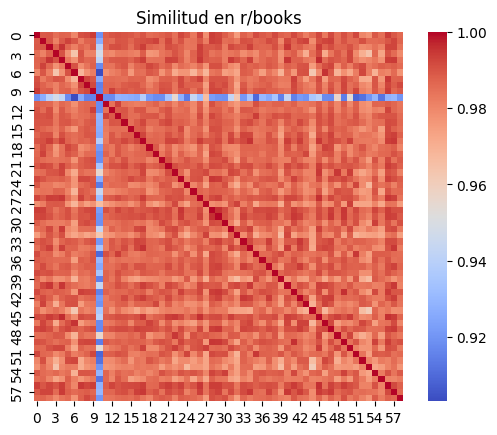

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matirz_similitud, annot=False, cmap='coolwarm', cbar=True, square=True)
plt.title(f'Similitud en r/books')
plt.show()

Podemos observar en este mapa de calor que en este subreddit hay una gran similaridad entre hilos, sin embargo, se pueden distinguir un que se desvían un poco más de esta similaridad tan alta en la línea 10, vamos a descubrir cuáles son exactamente.

In [20]:
# 1. Calculamos la media de similitud para cada fila (cada hilo)
# Restamos 1 porque la diagonal siempre es 1 (similitud consigo mismo)
mean_similarities = (matirz_similitud.sum(axis=1) - 1) / (matirz_similitud.shape[0] - 1)

# 2. Añadimos esta métrica a nuestro DataFrame original
books['similitud_media'] = mean_similarities

# 3. Ordenamos para ver los hilos MENOS similares al resto
hilos_intrusos = books.sort_values(by='similitud_media', ascending=True).head(1)

print("Hilos que menos encajan en el subreddit:")
print(hilos_intrusos[['texto_completo', 'similitud_media']])

Hilos que menos encajan en el subreddit:
                                       texto_completo  similitud_media
10  Name A book that you've read more than once Fo...         0.927605


In [8]:
print(matirz_similitud.min())

0.90321285


Vemos que efectivamente el hilos mencionado anteriormente es aquel que tiene una similaridad media menor y que por tanto parece no "encajar" tanto dentro de esta comunidad, aún así vemos que el valor mínimo es considerablemente alto ($0.927605$) y por tanto no podemos decir que se esté hablando de algo que no tenga nada que ver.

Ahora podemos representar estos vectores con un PCA de 2 dimensiones y ver una distribución en el espacio aproximada por estas dos primeras dimensiones de los hilos de este subreddit.

PCA

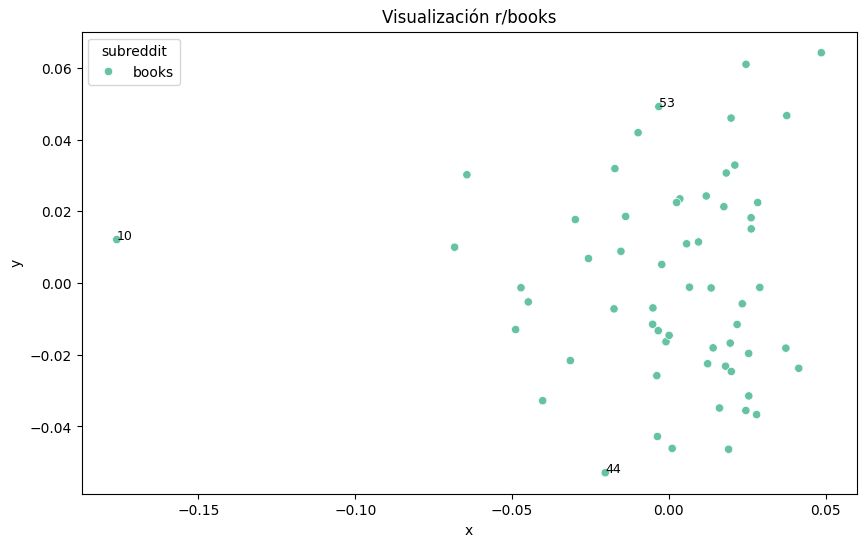

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(books['embedding']))

# Añadimos las coordenadas al DataFrame para poder graficar
books['x'] = puntos_2d[:, 0]
books['y'] = puntos_2d[:, 1]

# Realizamos el gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=books, x='x', y='y', hue='subreddit', palette='Set2')
plt.title("Visualización r/books")

# Identificamos los puntos más lejanos
for i in range(len(books)):
    if books['similitud_media'].iloc[i] < books['similitud_media'].quantile(0.05): # El 5% "peor"
        plt.text(books['x'].iloc[i], books['y'].iloc[i], str(i), fontsize=9)

En este caso, las dos primeras dimensiones captan perfectamente esta "diferencia" de similaridad encontrada en este subreddit, pues es capaz de representar estos hilos que menos encajan más alejados del resto.

COMPLETO

Pasamos ahora a realizar este mismo análisis con los 6 subreddits extraídos a la vez.

In [33]:
import pandas as pd

archivos_json = [
    "completo_travel.json", 
    "completo_LeagueOfLegends.json", 
    "completo_RandomThoughts.json",
    "completo_unpopularopinion.json",
    "completo_jobs.json",
    "completo_books.json"
]

# Lista para ir guardando los dataframes temporales
lista_dfs = []

# Cargamos cada archivo y lo añadimos a la lista
for archivo in archivos_json:
    temp_df = pd.read_json(archivo)
    lista_dfs.append(temp_df)

# Concatenamos todo en un solo DataFrame
df_total = pd.concat(lista_dfs, ignore_index=True)

# Definimos la función para preparar el texto de cada hilo (título + comentarios)
def preparar_texto_hilo(row):
    hilo = row['submissions']
    titulo = str(hilo.get('title', ''))
    texto_submission = str(hilo.get('selftext', ''))
    
    comentarios = hilo.get('comments', [])
    # Unimos comentarios y limpiamos saltos de línea (produce un error en FastText)
    texto_comentarios = " ".join([str(c.get('body', '')).replace('\n', ' ') for c in comentarios])
    
    return f"{titulo} {texto_submission} {texto_comentarios}".strip().replace('\n', ' ')

# Procesamos los textos y generamos los embeddings para todos los hilos extraídos
df_total['texto_completo'] = df_total.apply(preparar_texto_hilo, axis=1)

df_total['embedding'] = df_total['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x))

print(f"Completado. Total de hilos procesados: {len(df_total)}")
display(df_total[['subreddit', 'texto_completo', 'embedding']].head())

Completado. Total de hilos procesados: 354


,subreddit,texto_completo,embedding
0,travel,What are some cities where touristy areas are ...,"[-0.00066993403, -0.018163314, 0.07660348, 0.0..."
1,travel,Should I cancel my trip? hey 21F here and i’m ...,"[-0.0049153995, -0.02800265, 0.08077667, 0.004..."
2,travel,Is it a bad idea to go back to Japan again if ...,"[0.0023997475, -0.031742837, 0.082099, 0.00274..."
3,travel,I just took my first big international vacatio...,"[0.0008871933, -0.032703865, 0.08260299, 0.005..."
4,travel,Where is your favorite place to relax in Europ...,"[0.0007535079, -0.027056616, 0.07127587, 0.009..."


Generamos ahora los mapas de calor para los 6 subreddits.

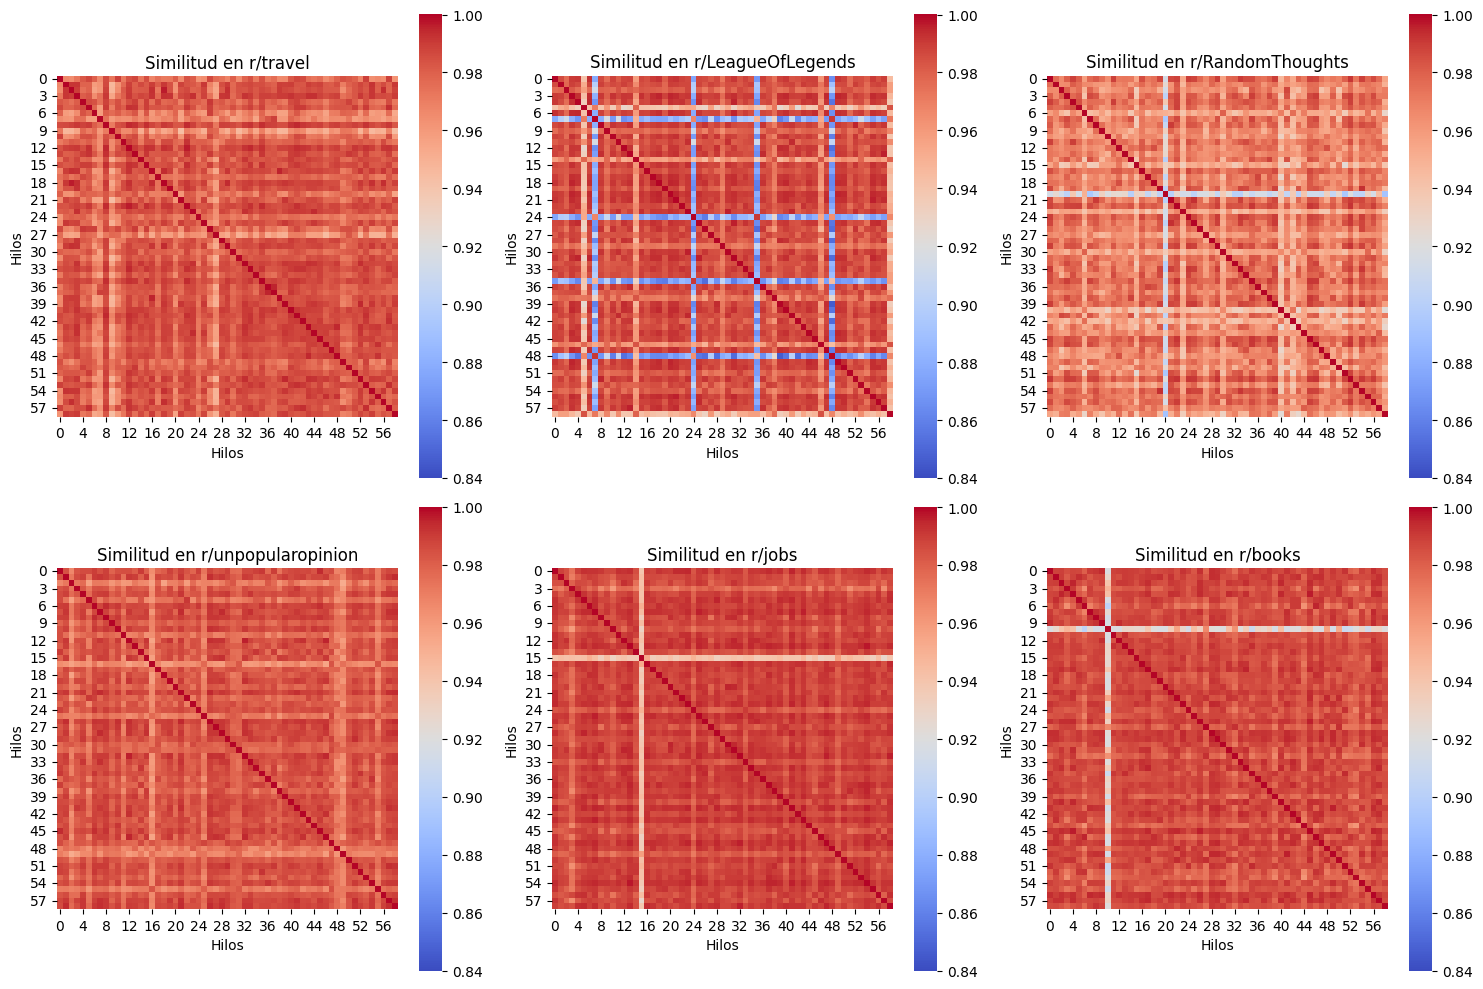

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

subreddits = df_total['subreddit'].unique()

ncols = 3
nrows = 2

# Preparamos la figura con subgráficos
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Iteramos sobre cada subreddit para generar su propio heatmap
for i, sub in enumerate(subreddits):
    # Filtramos los hilos que pertenecen solo a este subreddit
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Calculamos la matriz de similitud solo para esos hilos
    similitud_sub = cosine_similarity(list(df_sub['embedding']))
    
	# Calculamos la similitud media para cada hilo dentro de su subreddit para poder hacer el PCA posteriormente
    # y así solo iteramos por todo el dataset una vez
    mean_similarities = (similitud_sub.sum(axis=1) - 1) / (similitud_sub.shape[0] - 1)
    
    df_total.loc[df_total['subreddit'] == sub, 'similitud_media'] = mean_similarities
    
    # Dibujamos el heatmap
    sns.heatmap(similitud_sub, annot=False, cmap='coolwarm', ax=axes[i], 
                cbar=True, square=True, vmin=0.84)
    
    axes[i].set_title(f'Similitud en r/{sub}')
    axes[i].set_xlabel('Hilos')
    axes[i].set_ylabel('Hilos')

plt.tight_layout()
plt.show()

## REVISAR

Gracias a esta gráfica podemos hacernos una idea de la similaridad general que tienen estos subreddits, siendo notable que la primera fila tiene unos colores más claros y azulados, indicando que son menos coherentes entre sí que los subreddits de la segunda fila, que tienen unos colores rojos más intensos lo que indica que son más compactos en cuanto a similaridad de sus hilos, aunque también tienen algún que otro hilo que se diferencia notablemente.

Esto puede llegar a tener sentido si pensamos en los posibles hilos que se pueden generar en estos subreddits menos compactos. Tanto en **r/RandomThoughts** como en **r/books** se hablarán con frecuencia de temas muy dispares entre sí (hay libros de todo tipo y contenidos) y con resultados también impredecibles, pues habrá comentarios apoyando los posts y otros criticándolo o con una discusión en los comentarios, tal vez otros hilos están teniendo una simple conversación, y al tener temas tan dispares pues ayuda a este índice más bajo de similaridad, siendo la más notable (y con más sentido) la comunidad de **r/RandomThoughts**. En **r/travel** entendemos a partir de estos resultados que pasa algo parecido, pero no creemos que sea algo de la naturaleza del subreddit, como sí creemos que es el caso de las otras dos comunidades. 

En cuanto a las comunidades de la fila de abajo, parece que, aunque en menor medida, en la comunidad **r/unpopularopinion** ocurre algo similar a lo que ocurre en **r/RandomThoughts**, y esto cobra sentido pues en nuestra opinión podrían ser unas comunidades un tanto similares en cuanto a estilo de hilos y contenidos. En **r/jobs** y **r/LeagueOfLegends** destacan los hilos 15 y 50 respectivamente (ahora veremos de cuales se tratan), pero son comunidades generalmente similares y compactas, con algún que otro hilo suelto que difiere un poco de los demás (algo que es completamente normal).

Antes de pasar a realizar el PCA de los subreddits vamos a descubrir de qué tratan los hilos que menos encajan en cada subreddit para ver la razón de esta similaridad más baja.

HILOS MENOS SIMILARES

In [37]:
# Encontramos los índices de los hilos con la menor similitud media por subreddit
indices_minimos = df_total.groupby('subreddit')['similitud_media'].idxmin()

# Filtramos el DataFrame original usando esos índices
hilos_menos_similares = df_total.loc[indices_minimos]

hilos_menos_similares.index = hilos_menos_similares.index % 59
# Mostramos el resultado
display(hilos_menos_similares[['subreddit', 'similitud_media', 'texto_completo']])
for i in range(len(hilos_menos_similares)):
	print(f"Hilo menos similar en {hilos_menos_similares['subreddit'].iloc[i]}:\n {hilos_menos_similares['texto_completo'].iloc[i][:1000]}...\n")

,subreddit,similitud_media,texto_completo
48,LeagueOfLegends,0.883770,Karmine Corp vs. Movistar KOI / LEC 2025 Winte...
20,RandomThoughts,0.916757,What's the male equivalent for high heels and ...
10,books,0.927605,Name A book that you've read more than once Fo...
15,jobs,0.940059,"It's really getting crazy now. ""Take This Job..."
9,travel,0.960955,Do you have any favorite botanical gardens? I’...
16,unpopularopinion,0.964934,Tomato Soup is disgusting easily it is one of ...


Hilo menos similar en LeagueOfLegends:
 Karmine Corp vs. Movistar KOI / LEC 2025 Winter Playoffs - Upper Bracket Round 2 / Post-Match Discussion ###LEC 2025 WINTER                  [Official page](https://watch.lolesports.com/) | [Leaguepedia](https://lol.fandom.com/wiki/LEC/2025_Season/Winter_Season) | [Liquipedia](https://liquipedia.net/leagueoflegends/LEC/2025/Winter) | [Eventvods.com](https://eventvods.com/featured/lol?utm_source=reddit&utm_medium=subreddit&utm_campaign=post_match_threads) | [New to LoL](http://lol.gamepedia.com/New_To_League/Welcome)                 ---  ###Karmine Corp 2-0 Movistar KOI               **Karmine Corp move on to face G2 Esports in the upper bracket finals!**                                   **KC** | [Leaguepedia](https://lol.fandom.com/wiki/Karmine_Corp) | [Liquipedia](https://liquipedia.net/leagueoflegends/Karmine_Corp) | [Website](http://karminecorp.fr/) | [Twitter](https://www.twitter.com/KarmineCorp) | [Facebook](https://www.facebook.com/karmine

Averiguamos así de qué tratan y podemos intentar hacernos una idea de por qué estos hilos serían los que menos encajan en la comunidad:

- **r/LeagueOfLegends**: El hilo trata de una discusión activa sobre la actualidad de un torneo internacional que se estaba produciendo en la fecha de la publicación. Al organizarse únicamente tres torneos internacionales al año de este videojuego, es posible que no hayamos recogido otro hilos (o muy pocos) que se asemejen a este en nuestro corpus y por eso se aleja más de la norma de lo que es esta comunidad, porque en el día a día se hablarán de aspectos que tengan que ver con el juego en sí y no los torneos.
- **r/RandomThoughts**: Este hilo trata sobre *outfits* (vestimentas) de hombre atractivos, y a pesar de que esta comunidad ocupe un gran rango de temas, puede ser que este tipo de hilo de la gente comentando su opinión sobre *outfits* de hombre atractivos entrase más en una comunidad como **r/clothes** y no se parezca tanto a los demás hilos del mismo.
- **r/books**: En este caso, el culpable de que el hilo se aleje más de la norma de esta comunidad puede ser que los comentarios de esta publicación se dedican a enumerar libros sin ninguna explicación adicional aparente, entonces es más una enumeración o lista que una conversación.
- **r/jobs**: Este hilo está en la comunidad de "trabajos" pero los comentarios son en su mayoría una lista de canciones, por lo que es entendible que difiera bastante de la tónica general de la comunidad.
- **r/travel**: El hilo en este caso se centra en hablar más acerca de "jardines botánicos, fauna y flora" que de viajes o lugares, que es de lo que es la comunidad en principio.
- **r/unpopularopinion**: Este hilo trata sobre alguien a quien no le gusta la sopa de tomate y los usuarios en los comentarios le dan consejos sobre ingredientes o formas de hacerla para que pueda gustarle, eso puede hacer que parezca más un hilo perteneciente a **r/cooking** o similar pues los comentarios son intentos de recetas.

PCA

La mejor manera en la que podemos representar estos *sentence embeddings*, que tienen más de dos dimensiones, es mediante el uso de un PCA (*Principal Components Analisis*) porque permite quedarnos con las dos primeras dimensiones de estos *embeddings* sin perder mucha información y así poder representarlos en una gráfica de puntos.

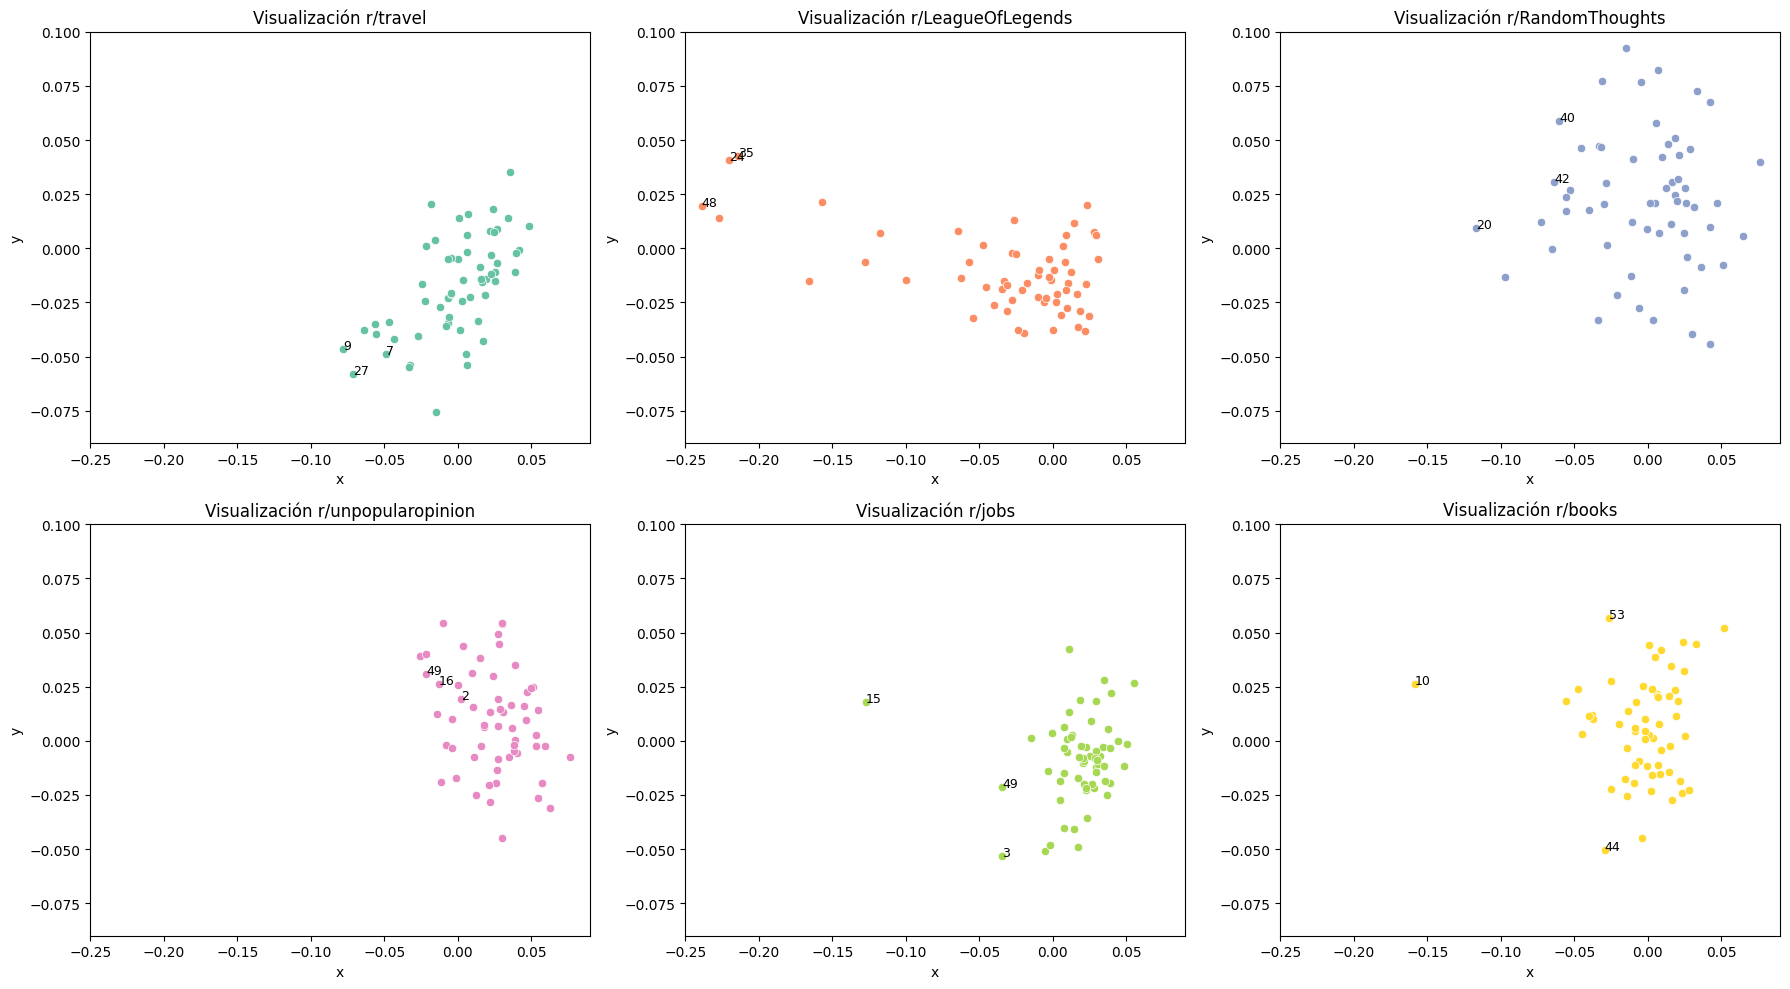

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(df_total['embedding']))

# Añadimos las coordenadas al DataFrame para poder graficar
df_total['x'] = puntos_2d[:, 0]
df_total['y'] = puntos_2d[:, 1]

# Preparamos la cuadrícula de subgráficas
subreddits = df_total['subreddit'].unique()
ncols = 3
nrows = 2

palette = sns.color_palette("Set2", len(subreddits))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente

# Dibujamosuna gráfica por cada subreddit
for i, sub in enumerate(subreddits):
    # Filtramos los datos solo para esta comunidad
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Dibujamos el scatterplot en el subgráfico correspondiente 
    sns.scatterplot(data=df_sub, x='x', y='y',color=palette[i], ax=axes[i])
    axes[i].set_xlim(-0.25, 0.09)
    axes[i].set_ylim(-0.09, 0.1)
    axes[i].set_title(f"Visualización r/{sub}")
    
    # Calculamos el 5% "peor" (menos similares) SOLO para este subreddit
    umbral_outliers = df_sub['similitud_media'].quantile(0.05)
    
    # Identificamos los puntos más lejanos
    for idx, row in df_sub.iterrows():
        if row['similitud_media'] < umbral_outliers:
            # Ponemos el índice original de cada subreddit
            axes[i].text(row['x'], row['y'], str(idx%59), fontsize=9, color='black')

plt.tight_layout()
plt.show()

Podemos observar que, aunque en general los puntos outliers corresponden con los puntos más alejados de la representación del PCA, no ocurre en todos los casos, como se ve en **r/unpopularopinion** por ejemplo (el más notable), pues la similaridad del coseno media con los hilos de su subreddit se calcula con todas las dimensiones del embedding y puede ser que, al "aplastar" todas esas dimensiones en solo 2 para poder representarlas, la diferencia que se ha calculado anteriormente no coincida visualmente con estas dos primeras dimensiones representadas, por eso vemos que los hilos menos similares en **r/unpopularopinion**, "visualmente" no están alejados en esta representación 2D, porque estas diferencias de similaridad residen en un espacio de mayor dimensionalidad en estos casos.

A simple vista podemos plantear la hipótesis de que esta representación parece ser coherente con los mapas de calor anteriores y por tanto los mapas de calor más oscuros corresponderán con los gráficos más compactos y viceversa, pero para asegurarnos vamos a calcular los centros de gravedad de cada gráfica y las diferencias absolutas con todos los puntos para analizar la compactación de estos grupos.

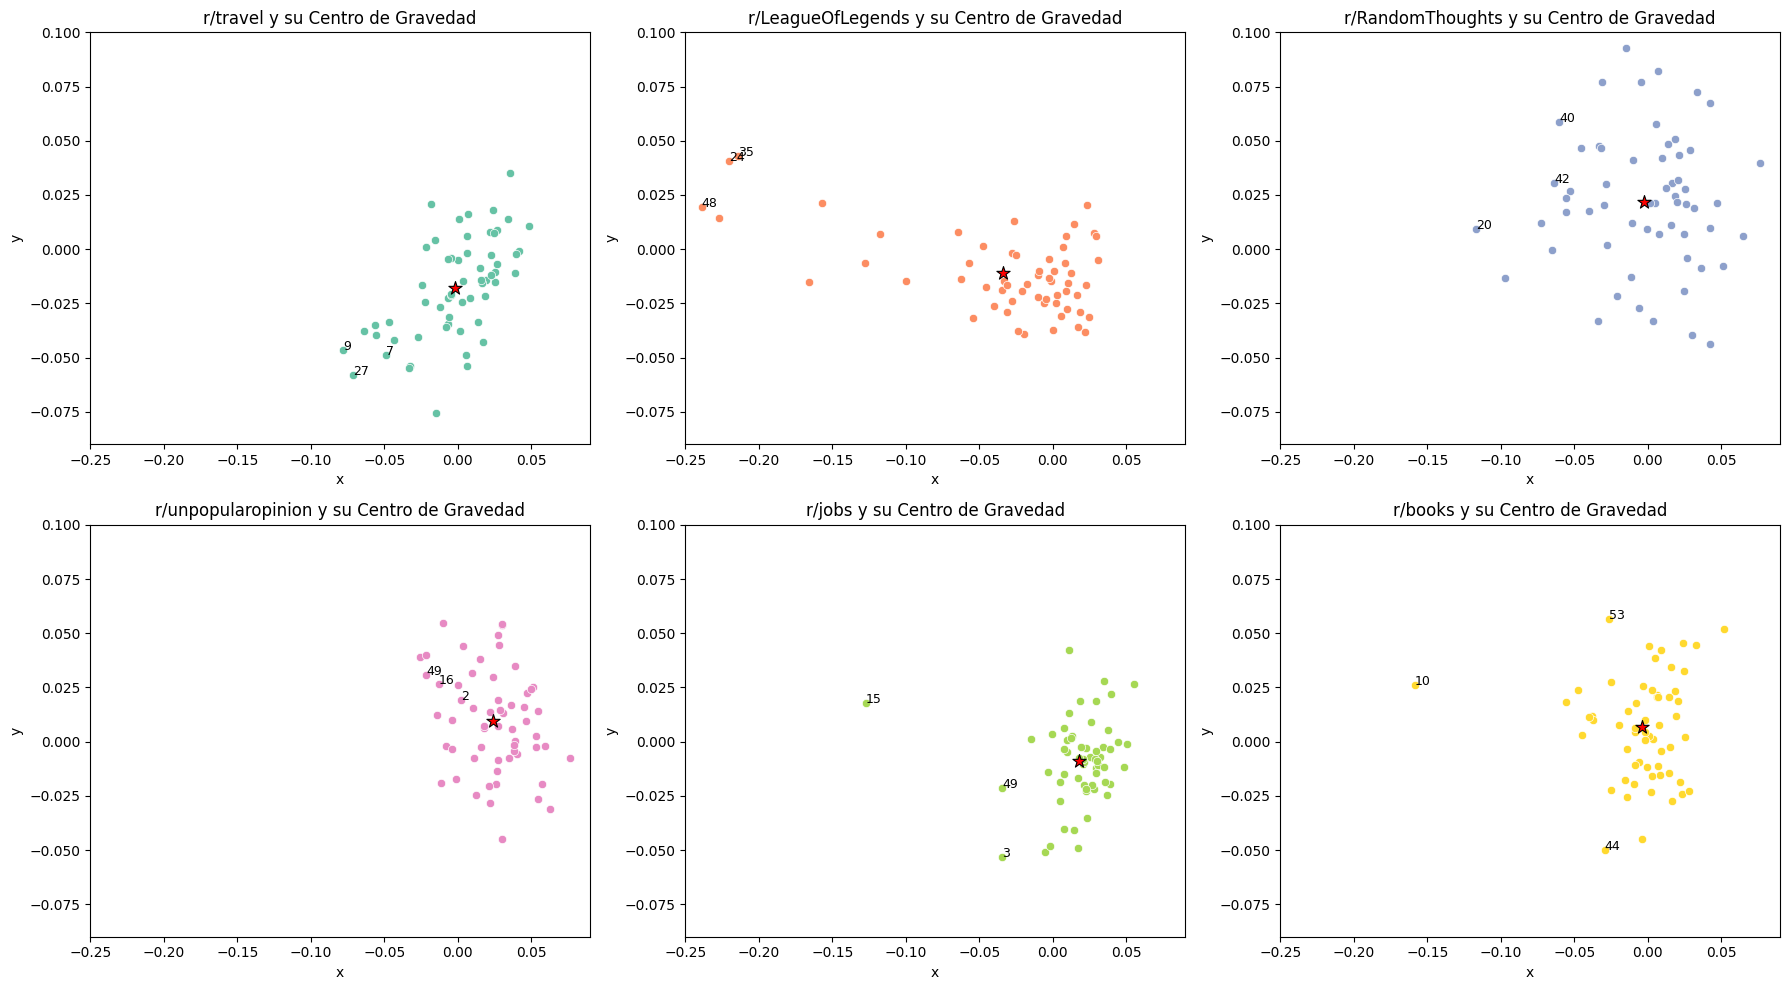

Ranking de Compactación (Menor valor = Más compacto):
          subreddit  dispersion_media
0              jobs          0.024161
1  unpopularopinion          0.029711
2             books          0.030182
3            travel          0.032488
4    RandomThoughts          0.044753
5   LeagueOfLegends          0.051574


In [39]:
import numpy as np
# Calculamos el centro de gravedad (media de x e y) por grupo
centroides = df_total.groupby('subreddit')[['x', 'y']].mean().reset_index()
centroides.columns = ['subreddit', 'centro_x', 'centro_y']

# Unimos los centroides al dataframe original para calcular distancias
df_calculo = df_total.merge(centroides, on='subreddit')

# Calculamos la diferencia absoluta (Distancia Euclídea) de cada punto a su centroide
df_calculo['distancia_al_centro'] = np.sqrt(
    (df_calculo['x'] - df_calculo['centro_x'])**2 + 
    (df_calculo['y'] - df_calculo['centro_y'])**2
)

# Calculamos el promedio de estas distancias por subreddit
compactacion = df_calculo.groupby('subreddit')['distancia_al_centro'].mean().sort_values().reset_index()
compactacion.columns = ['subreddit', 'dispersion_media']

# Preparamos la cuadrícula de subgráficas
subreddits = df_total['subreddit'].unique()
ncols = 3
nrows = 2

palette = sns.color_palette("Set2", len(subreddits))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente

# Dibujamosuna gráfica por cada subreddit
for i, sub in enumerate(subreddits):
    # Filtramos los datos solo para esta comunidad
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Dibujamos el scatterplot en el subgráfico correspondiente 
    sns.scatterplot(data=df_sub, x='x', y='y',color=palette[i], ax=axes[i])
    sns.scatterplot(data=centroides[centroides['subreddit'] == sub], x='centro_x', y='centro_y',
                    marker ='*', s=100, edgecolor='black', color='red', ax=axes[i], legend=False)
    axes[i].set_xlim(-0.25, 0.09)
    axes[i].set_ylim(-0.09, 0.1)
    axes[i].set_title(f"r/{sub} y su Centro de Gravedad")
    
    # Calculamos el 5% "peor" (menos similares) SOLO para este subreddit
    umbral_outliers = df_sub['similitud_media'].quantile(0.05)
    
    # Identificamos los puntos más lejanos
    for idx, row in df_sub.iterrows():
        if row['similitud_media'] < umbral_outliers:
            # Ponemos el índice original de cada subreddit
            axes[i].text(row['x'], row['y'], str(idx%59), fontsize=9, color='black')

plt.tight_layout()
plt.show()

print("Ranking de Compactación (Menor valor = Más compacto):")
print(compactacion)

Comprobamos de esta manera que la hipótesis planteada es cierta y los gráficos más compactos corresponden con los mapas de calor más oscuros y viceversa.

### CORPUS "LIMPIO"

Ahora realizaremos los mismos análisis anteriores para el Corpus Limpio para descubrir si se produce alguna mejora al quitar *stopwords* y *emojis*.

Únicamente tendremos que cambiar los archivos de entrada, por lo que el código es el mismo.

Pasamos ahora a realizar este mismo análisis con los 6 subreddits extraídos a la vez.

In [40]:
import pandas as pd

archivos_json = [
    "limpio_travel.json",
    "limpio_LeagueOfLegends.json", 
    "limpio_RandomThoughts.json",
    "limpio_unpopularopinion.json",
    "limpio_jobs.json",
    "limpio_books.json" 

]

# Lista para ir guardando los dataframes temporales
lista_dfs = []

# Cargamos cada archivo y lo añadimos a la lista
for archivo in archivos_json:
    temp_df = pd.read_json(archivo)
    lista_dfs.append(temp_df)

# Concatenamos todo en un solo DataFrame
df_total = pd.concat(lista_dfs, ignore_index=True)

# Definimos la función para preparar el texto de cada hilo (título + comentarios)
def preparar_texto_hilo(row):
    hilo = row['submissions']
    titulo = str(hilo.get('title', ''))
    texto_submission = str(hilo.get('selftext', ''))
    
    comentarios = hilo.get('comments', [])
    # Unimos comentarios y limpiamos saltos de línea (produce un error en FastText)
    texto_comentarios = " ".join([str(c.get('body', '')).replace('\n', ' ') for c in comentarios])
    
    return f"{titulo} {texto_submission} {texto_comentarios}".strip().replace('\n', ' ')

# Procesamos los textos y generamos los embeddings para todos los hilos extraídos
df_total['texto_completo'] = df_total.apply(preparar_texto_hilo, axis=1)

df_total['embedding'] = df_total['texto_completo'].apply(lambda x: ft_model.get_sentence_vector(x))

print(f"Completado. Total de hilos procesados: {len(df_total)}")
display(df_total[['subreddit', 'texto_completo', 'embedding']].head())

Completado. Total de hilos procesados: 354


,subreddit,texto_completo,embedding
0,travel,What cities touristy areas located near sketch...,"[-0.017075699, -0.017827477, 0.06470923, 0.001..."
1,travel,Should cancel trip hey 21F going london amster...,"[-0.02010477, -0.032267354, 0.073867634, 0.002..."
2,travel,Is bad idea go back Japan one country F19 got ...,"[-0.013257206, -0.032074876, 0.08275882, 0.003..."
3,travel,took first big international vacation expected...,"[-0.013990268, -0.03013797, 0.07675892, 0.0044..."
4,travel,Where favorite place relax Europe want hear fa...,"[-0.012221555, -0.02062098, 0.063356504, 0.009..."


Generamos ahora los mapas de calor para los 6 subreddits.

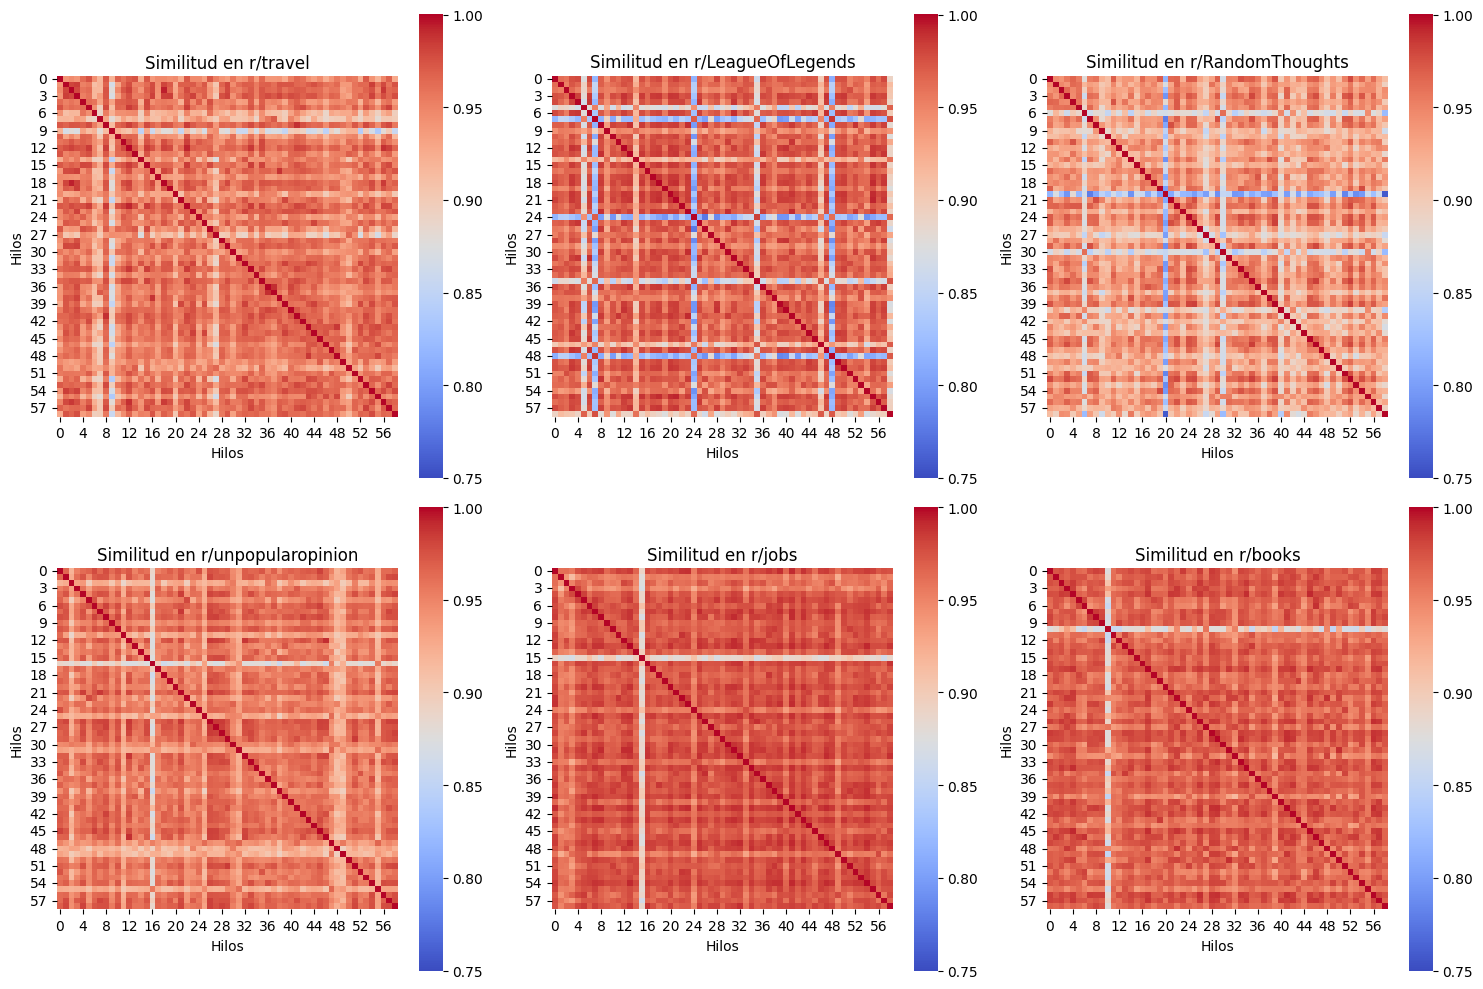

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

subreddits = df_total['subreddit'].unique()

ncols = 3
nrows = 2

# Preparamos la figura con subgráficos
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5 * nrows))
axes = axes.flatten() # Aplanamos para iterar fácilmente

# Iteramos sobre cada subreddit para generar su propio heatmap
for i, sub in enumerate(subreddits):
    # Filtramos los hilos que pertenecen solo a este subreddit
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Calculamos la matriz de similitud solo para esos hilos
    similitud_sub = cosine_similarity(list(df_sub['embedding']))
    
	# Calculamos la similitud media para cada hilo dentro de su subreddit para poder hacer el PCA posteriormente
    # y así solo iteramos por todo el dataset una vez
    mean_similarities = (similitud_sub.sum(axis=1) - 1) / (similitud_sub.shape[0] - 1)
    
    df_total.loc[df_total['subreddit'] == sub, 'similitud_media'] = mean_similarities
    
    # Dibujamos el heatmap
    sns.heatmap(similitud_sub, annot=False, cmap='coolwarm', ax=axes[i], 
                cbar=True, square=True, vmin=0.75)
    
    axes[i].set_title(f'Similitud en r/{sub}')
    axes[i].set_xlabel('Hilos')
    axes[i].set_ylabel('Hilos')

plt.tight_layout()
plt.show()

Observamos una notable bajada en los índices de similaridad de la mayoría de los subreddits, viendo como los 6 mapas de calor se han vuelto bastante más claros que los anteriores. Esto, según los resultados que hemos obtenido con el Corpus Completo, indica que habrá una mayor dispersión general en estas comunidades.

Antes de pasar a realizar el PCA de los subreddits vamos a descubrir de qué tratan los hilos que menos encajan en cada subreddit para ver la razón de esta similaridad más baja.

HILOS MENOS SIMILARES

In [43]:
# Encontramos los índices de los hilos con la menor similitud media por subreddit
indices_minimos = df_total.groupby('subreddit')['similitud_media'].idxmin()

# Filtramos el DataFrame original usando esos índices
hilos_menos_similares = df_total.loc[indices_minimos]

hilos_menos_similares.index = hilos_menos_similares.index % 59
# Mostramos el resultado
display(hilos_menos_similares[['subreddit', 'similitud_media', 'texto_completo']])
for i in range(len(hilos_menos_similares)):
	print(f"Hilo menos similar en {hilos_menos_similares['subreddit'].iloc[i]}:\n {hilos_menos_similares['texto_completo'].iloc[i][:1000]}...\n")

,subreddit,similitud_media,texto_completo
24,LeagueOfLegends,0.841249,LEC Winter 2025 Week Day Live Discussion LEC 2...
20,RandomThoughts,0.826362,What 's male equivalent high heels red lipstic...
10,books,0.888939,Name book 've read For top head 've read Steph...
15,jobs,0.887436,It 's really getting crazy `` Take This Job S...
9,travel,0.888574,Do favorite botanical gardens always looking a...
16,unpopularopinion,0.888277,Tomato Soup disgusting easily one grossest foo...


Hilo menos similar en LeagueOfLegends:
 LEC Winter 2025 Week Day Live Discussion LEC 2025 Winter Lolesports https //lolesports.com/ Leaguepedia https //lol.fandom.com/wiki/LEC/2025_Season/Winter_Season Eventvods.com https //eventvods.com New LoL https //lol.fandom.com/wiki/New_To_League/Welcome Today 's matches played Patch 25.S1.1 https //www.leagueoflegends.com/en-gb/news/game-updates/patch-25-s1-1-notes/ Today 's Matches |Match|PST|EST|CET|KST -- -- -- -- -- -- -- -- -- -- -- -- |1|VIT vs RGE|9:00 AM|12:00 PM|18:00|02:00 |2|FNC vs BDS|9:45 AM|12:45 PM|18:45|02:45 |3|G2 vs GX|10:30 AM|1:30 PM|19:30|03:30 |4|KC vs TH|11:15 AM|2:15 PM|20:15|04:15 |5|SK vs MKOI|12:00 PM|3:00 PM|21:00|05:00 All matches Best Streams Stream Twitch https //twitch.tv/lec Stream YouTube https //www.youtube.com/c/LEC/ Stream Lolesports http //watch.lolesports.com Audio-Only Cast Stream http //leagueday.live/ Comment Stream http //reddit-stream.com/comments/auto -- Standings Team Region Record Information -- --

En este caso, los hilos que menos encajan en los subreddits se han mantenido igual a excepción de uno. En la comunidad **r/LeagueOfLegends** ahora ha aparecido un hilo con una similaridad media menor. Es probable que se deba a que este hilo trata de una discusión sobre un partido de un torneo a nivel regional y se encuentre jerga local, que al eliminar tanto *stopwords* como *emojis* de posibles reacciones y comentarios, el hilo sobre el torneo internacional, que era el más alejado con el Corpus Completo, se haya quedado con un lenguaje y vocabulario más general que "encaje" más en el tema central del subreddit, que este hilo que se restringe a una zona geográfica más pequeña.

PCA

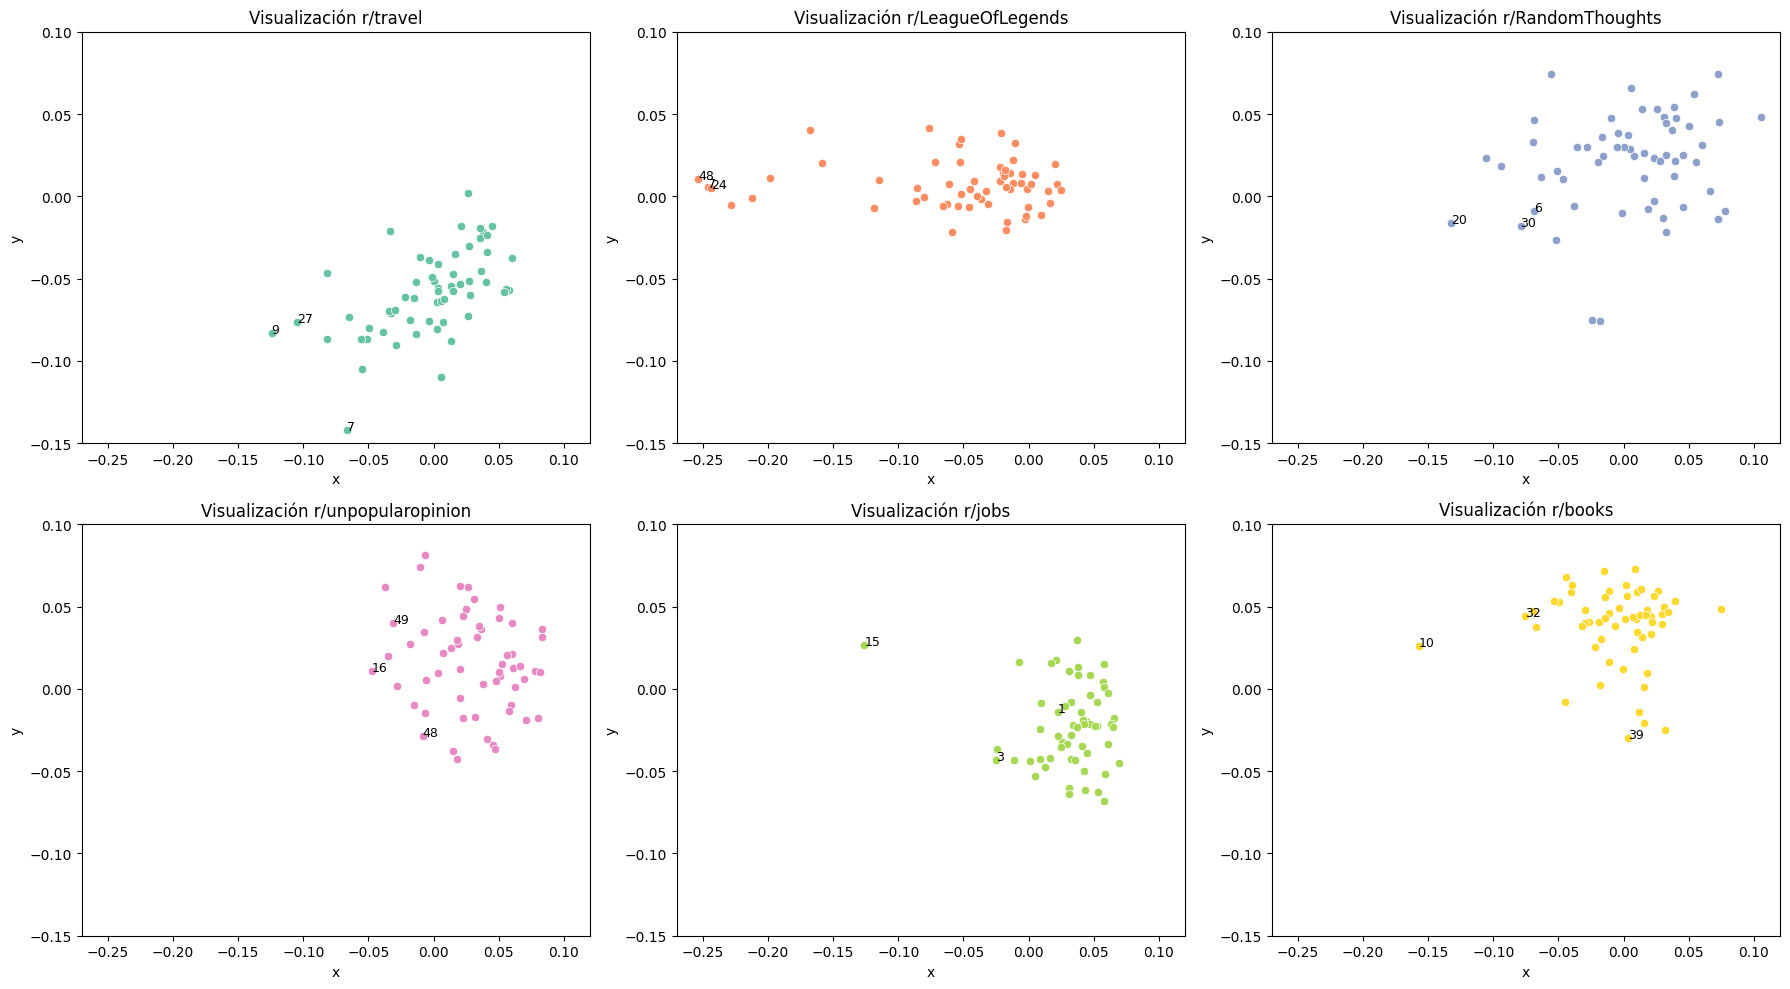

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos dimensiones a 2D
pca = PCA(n_components=2)
puntos_2d = pca.fit_transform(list(df_total['embedding']))

# Añadimos las coordenadas al DataFrame para poder graficar
df_total['x'] = puntos_2d[:, 0]
df_total['y'] = puntos_2d[:, 1]

# Preparamos la cuadrícula de subgráficas
subreddits = df_total['subreddit'].unique()
ncols = 3
nrows = 2

palette = sns.color_palette("Set2", len(subreddits))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente

# Dibujamosuna gráfica por cada subreddit
for i, sub in enumerate(subreddits):
    # Filtramos los datos solo para esta comunidad
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Dibujamos el scatterplot en el subgráfico correspondiente 
    sns.scatterplot(data=df_sub, x='x', y='y',color=palette[i], ax=axes[i])
    axes[i].set_xlim(-0.27, 0.12)
    axes[i].set_ylim(-0.15, 0.1)
    axes[i].set_title(f"Visualización r/{sub}")
    
    # Calculamos el 5% "peor" (menos similares) SOLO para este subreddit
    umbral_outliers = df_sub['similitud_media'].quantile(0.05)
    
    # Identificamos los puntos más lejanos
    for idx, row in df_sub.iterrows():
        if row['similitud_media'] < umbral_outliers:
            # Ponemos el índice original de cada subreddit
            axes[i].text(row['x'], row['y'], str(idx%59), fontsize=9, color='black')

plt.tight_layout()
plt.show()

A simple vista, estos gráficos de puntos parecen ser más densos que los anteriores, pero este hecho es simplemente resultado de un cambio de escala en los ejes mostrados, porque hemos tenido que ajustar dichos ejes y hacerlos más amplios para poder captar todas las instancias en esta ocasión, porque realmente hay más dispersión cómo venían indicando los mapas de calor.

Ahora calculamos los centros de gravedad de cada gráfico y mostramos los índices de dispersión actualizados.

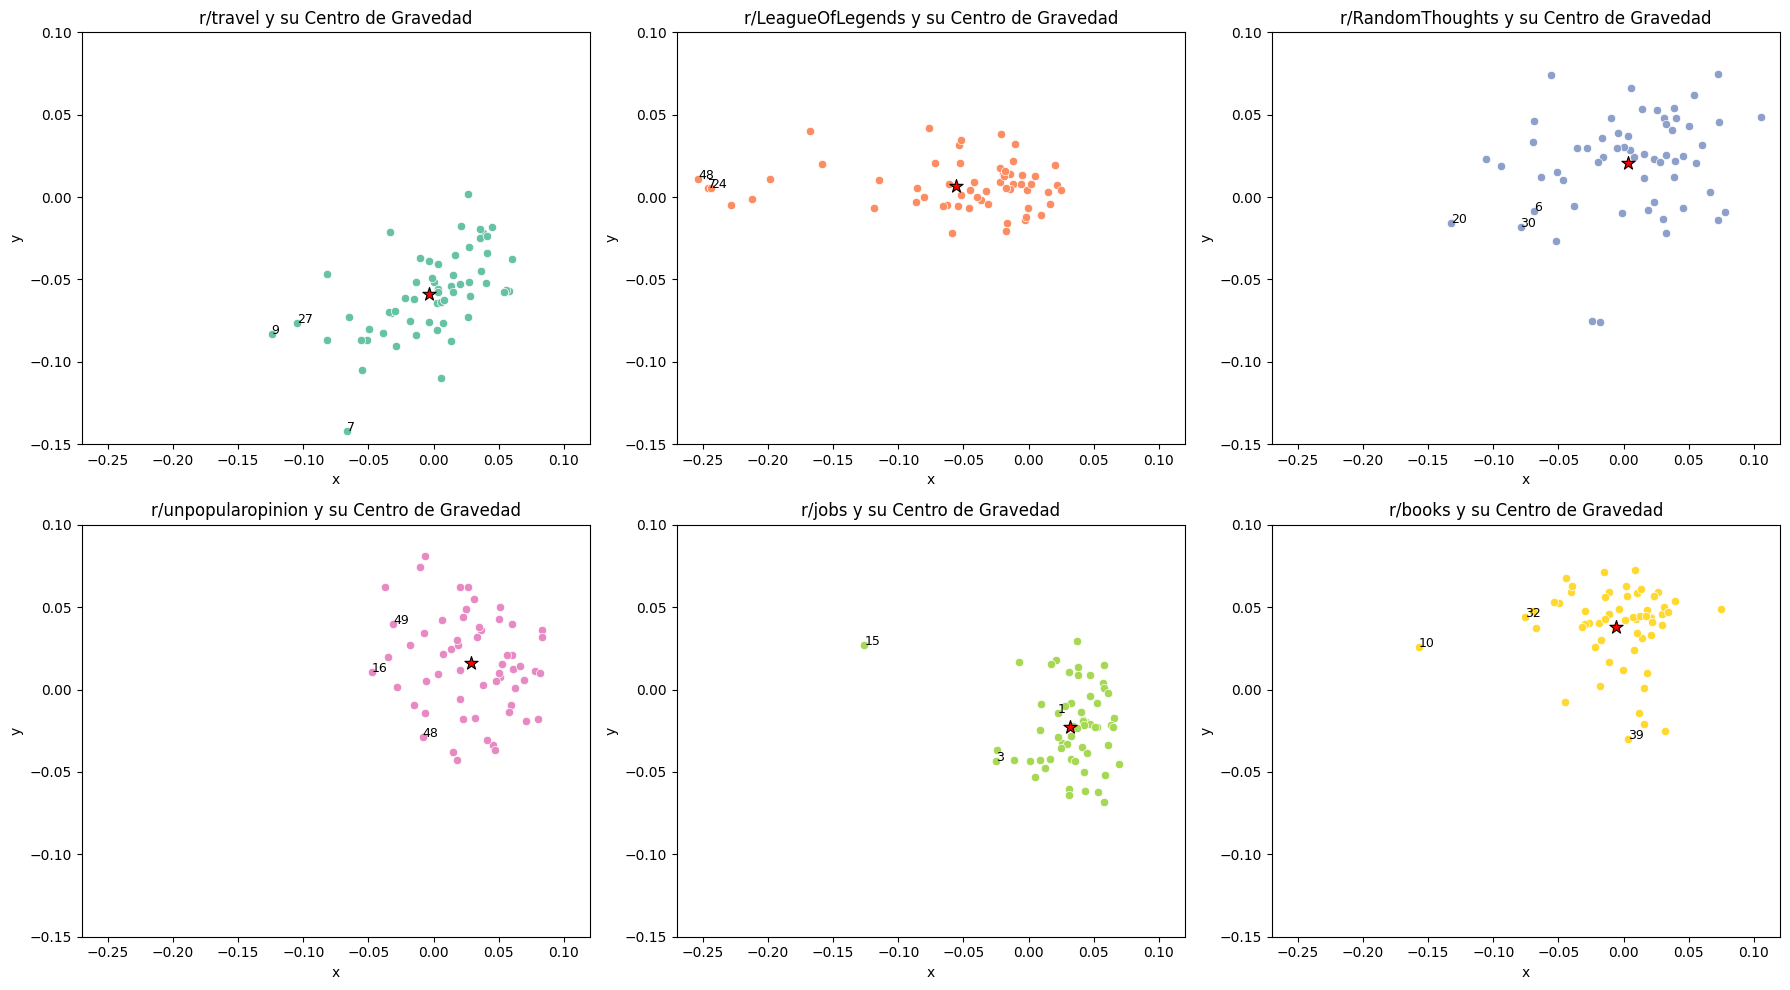

Ranking de Compactación (Menor valor = Más compacto):
          subreddit  dispersion_media
0              jobs          0.030917
1             books          0.035194
2  unpopularopinion          0.040797
3            travel          0.040835
4    RandomThoughts          0.050567
5   LeagueOfLegends          0.055812


In [45]:
import numpy as np
# Calculamos el centro de gravedad (media de x e y) por grupo
centroides = df_total.groupby('subreddit')[['x', 'y']].mean().reset_index()
centroides.columns = ['subreddit', 'centro_x', 'centro_y']

# Unimos los centroides al dataframe original para calcular distancias
df_calculo = df_total.merge(centroides, on='subreddit')

# Calculamos la diferencia absoluta (Distancia Euclídea) de cada punto a su centroide
df_calculo['distancia_al_centro'] = np.sqrt(
    (df_calculo['x'] - df_calculo['centro_x'])**2 + 
    (df_calculo['y'] - df_calculo['centro_y'])**2
)

# Calculamos el promedio de estas distancias por subreddit
compactacion = df_calculo.groupby('subreddit')['distancia_al_centro'].mean().sort_values().reset_index()
compactacion.columns = ['subreddit', 'dispersion_media']

# Preparamos la cuadrícula de subgráficas
subreddits = df_total['subreddit'].unique()
ncols = 3
nrows = 2

palette = sns.color_palette("Set2", len(subreddits))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Aplanamos para poder iterar fácilmente

# Dibujamosuna gráfica por cada subreddit
for i, sub in enumerate(subreddits):
    # Filtramos los datos solo para esta comunidad
    df_sub = df_total[df_total['subreddit'] == sub]
    
    # Dibujamos el scatterplot en el subgráfico correspondiente 
    sns.scatterplot(data=df_sub, x='x', y='y',color=palette[i], ax=axes[i])
    sns.scatterplot(data=centroides[centroides['subreddit'] == sub], x='centro_x', y='centro_y',
                    marker ='*', s=100, edgecolor='black', color='red', ax=axes[i], legend=False)
    axes[i].set_xlim(-0.27, 0.12)
    axes[i].set_ylim(-0.15, 0.1)
    axes[i].set_title(f"r/{sub} y su Centro de Gravedad")
    
    # Calculamos el 5% "peor" (menos similares) SOLO para este subreddit
    umbral_outliers = df_sub['similitud_media'].quantile(0.05)
    
    # Identificamos los puntos más lejanos
    for idx, row in df_sub.iterrows():
        if row['similitud_media'] < umbral_outliers:
            # Ponemos el índice original de cada subreddit
            axes[i].text(row['x'], row['y'], str(idx%59), fontsize=9, color='black')

plt.tight_layout()
plt.show()

print("Ranking de Compactación (Menor valor = Más compacto):")
print(compactacion)

En base a estos resultados concluimos que, al eliminar *stopwords* y *emojis* de las publicaciones y comentarios de estas seis comunidades seleccionadas, se generan una mayor dispersión y unos índices de similaridad más bajos en todos los casos. Este hecho altera los resultados en el sentido de que no se trata de una variación lineal y que se aplique por igual a todos los hilos (porque si no se mantendrían las similaridades pero en una escala distinta), sino que produce que se detecten hilos que antes se detectaban como más similares empiecen a descender y viceversa.
 
Podemos fijarnos que en la mayoría de gráficas, aunque el hilo más alejado sea el mismo, uno o los otros dos representados por el umbral varían con respecto a la versión con el Corpus Completo.

Esto implica que las *stopwords* y los *emojis* juegan un papel relativamente importante a la hora de "enmascarar" el tema central de algunos hilos.
